# Task-1

In [90]:
import numpy as np

# Matrix
A = np.array([
    [4., 1.],
    [2., 3.]
])

# NumPy verification
vals, vecs = np.linalg.eig(A)

print("Matrix A:")
print(A)

print("\nEigenvalues:")
print(vals)

print("\nEigenvectors (columns):")
print(vecs)

# Hand-computed eigenvectors
v1 = np.array([1., 1.])
v2 = np.array([1., -2.])

# Verify Av = lambda*v
print("\nVerification for lambda = 5:")
print("A @ v1 =", A @ v1)
print("5 * v1 =", 5 * v1)
print("Equal:", np.allclose(A @ v1, 5 * v1)) 
#np.allclose() checks whether two numerical arrays are approximately equal.beacause somtime data is not exactly equal . example: 5.0000000001     5.0000000000

print("\nVerification for lambda = 2:")
print("A @ v2 =", A @ v2)
print("2 * v2 =", 2 * v2)
print("Equal:", np.allclose(A @ v2, 2 * v2))

Matrix A:
[[4. 1.]
 [2. 3.]]

Eigenvalues:
[5. 2.]

Eigenvectors (columns):
[[ 0.70710678 -0.4472136 ]
 [ 0.70710678  0.89442719]]

Verification for lambda = 5:
A @ v1 = [5. 5.]
5 * v1 = [5. 5.]
Equal: True

Verification for lambda = 2:
A @ v2 = [ 2. -4.]
2 * v2 = [ 2. -4.]
Equal: True


# Task-2

Eigenvalues: [4. 2.]
Eigenvectors:
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


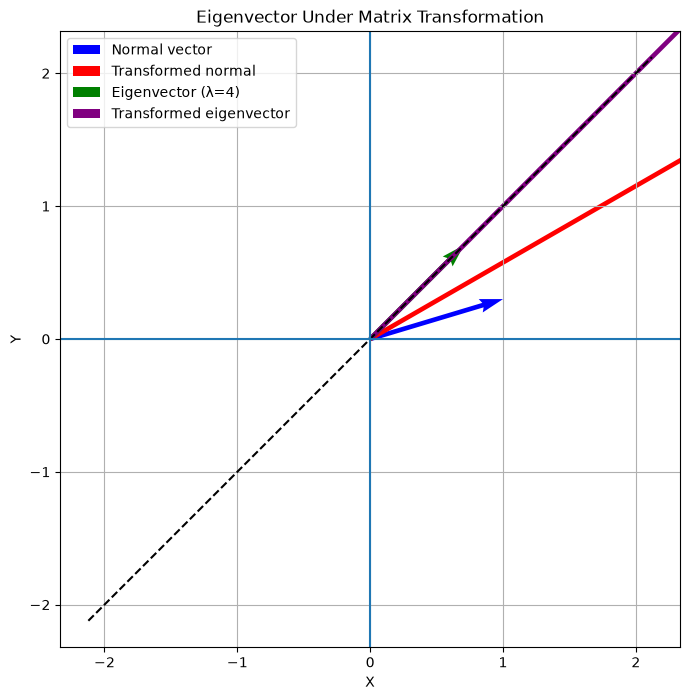

In [122]:
import numpy as np
import matplotlib.pyplot as plt

# Matrix
A = np.array([
    [3., 1.],
    [1., 3.]
])

# Find eigenvalues and eigenvectors
vals, vecs = np.linalg.eig(A)

print("Eigenvalues:", vals)
print("Eigenvectors:")
print(vecs)

# Eigenvector
ev = vecs[:, 0]

# Normal vector (not an eigenvector)
normal = np.array([1., 0.3])

# Transform both vectors
ev_transformed = A @ ev
normal_transformed = A @ normal

# Create plot
plt.figure(figsize=(8, 8))

# Normal vector - before
plt.quiver(
    0, 0,
    normal[0], normal[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="blue",
    label="Normal vector"
)

# Normal vector - after
plt.quiver(
    0, 0,
    normal_transformed[0], normal_transformed[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="red",
    label="Transformed normal"
)

# Eigenvector - before
plt.quiver(
    0, 0,
    ev[0], ev[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="green",
    label=f"Eigenvector (λ={vals[0]:.0f})"
)

# Eigenvector - after
plt.quiver(
    0, 0,
    ev_transformed[0], ev_transformed[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="purple",
    label="Transformed eigenvector"
)

# Eigenvector line

t = np.linspace(-3, 3, 100)

plt.plot(
    t * ev[0],
    t * ev[1],
    "--",
    color="black",
)

# Axis
plt.axhline(0)
plt.axvline(0)

plt.xlim(-5, 5)
plt.ylim(-5, 5)

plt.xlabel("X")
plt.ylabel("Y")

plt.title("Eigenvector Under Matrix Transformation")

plt.grid(True)
plt.legend()
plt.axis("equal")

plt.show()

# Task-3

In [123]:
# 1. Create a 6 × 4 matrix

M = np.array([
    [1, 2, 3, 4],
    [2, 4, 6, 8],
    [3, 6, 9, 12],
    [4, 8, 12, 16],
    [5, 10, 15, 20],
    [6, 12, 18, 24]
])

print("Original matrix:")
print(M)

print("\nShape of M:")
print(M.shape)

Original matrix:
[[ 1  2  3  4]
 [ 2  4  6  8]
 [ 3  6  9 12]
 [ 4  8 12 16]
 [ 5 10 15 20]
 [ 6 12 18 24]]

Shape of M:
(6, 4)


In [124]:
# ------------------------------------------------
# 2. Apply SVD
# ------------------------------------------------

U, s, Vt = np.linalg.svd(M, full_matrices=False)

print("\nShape of U:", U.shape)
print("Shape of s:", s.shape)
print("Shape of Vt:", Vt.shape)

print("\nSingular values:")
print(s)
# 3. Reconstruct the full matrix

M_reconstructed = U @ np.diag(s) @ Vt

print("\nReconstructed matrix:")
print(M_reconstructed)


# Check whether reconstructed matrix
# is approximately equal to original

print("\nDoes reconstruction match original")
print(np.allclose(M, M_reconstructed))


Shape of U: (6, 4)
Shape of s: (4,)
Shape of Vt: (4, 4)

Singular values:
[5.22494019e+01 4.11931968e-15 1.10831496e-31 2.77538806e-32]

Reconstructed matrix:
[[ 1.  2.  3.  4.]
 [ 2.  4.  6.  8.]
 [ 3.  6.  9. 12.]
 [ 4.  8. 12. 16.]
 [ 5. 10. 15. 20.]
 [ 6. 12. 18. 24.]]

Does reconstruction match original
True


In [125]:
# 4. Create a rank-k approximation

def rank_k(k):
    return U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]

In [126]:
# 5. Calculate relative error

for k in [1, 2, 3]:
    
    M_k = rank_k(k)
    
    error = np.linalg.norm(M - M_k) / np.linalg.norm(M)
    
    print(f"\nRank {k}")
    print("Approximation:")
    print(M_k)
    print("Relative error:", error)


Rank 1
Approximation:
[[ 1.  2.  3.  4.]
 [ 2.  4.  6.  8.]
 [ 3.  6.  9. 12.]
 [ 4.  8. 12. 16.]
 [ 5. 10. 15. 20.]
 [ 6. 12. 18. 24.]]
Relative error: 3.7436630950676154e-16

Rank 2
Approximation:
[[ 1.  2.  3.  4.]
 [ 2.  4.  6.  8.]
 [ 3.  6.  9. 12.]
 [ 4.  8. 12. 16.]
 [ 5. 10. 15. 20.]
 [ 6. 12. 18. 24.]]
Relative error: 3.854134401045861e-16

Rank 3
Approximation:
[[ 1.  2.  3.  4.]
 [ 2.  4.  6.  8.]
 [ 3.  6.  9. 12.]
 [ 4.  8. 12. 16.]
 [ 5. 10. 15. 20.]
 [ 6. 12. 18. 24.]]
Relative error: 3.854134401045861e-16


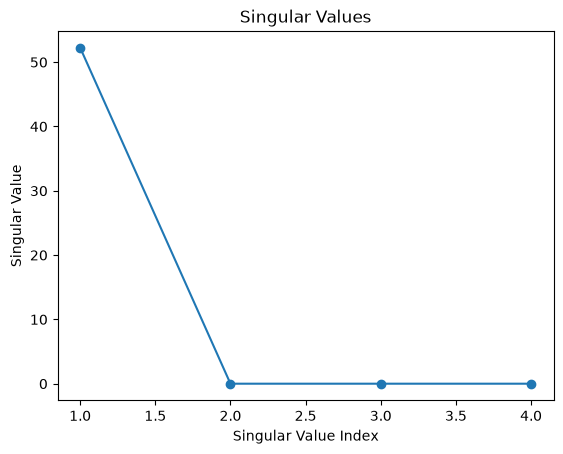

In [127]:
# 6. Plot singular values

plt.plot(
    range(1, len(s) + 1),
    s,
    marker="o"
)

plt.xlabel("Singular Value Index")
plt.ylabel("Singular Value")
plt.title("Singular Values")

plt.show()

# Task-4

Image shape: (300, 400)


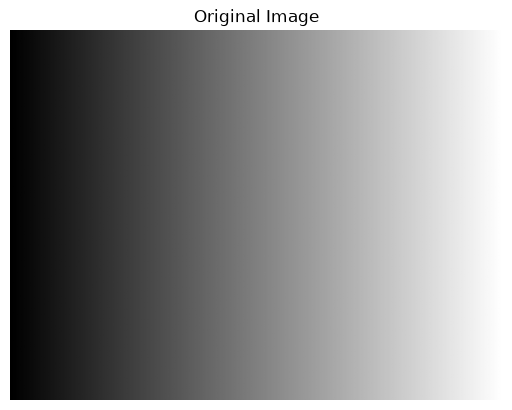

In [128]:
# 1. Create a grayscale image

image = np.tile(
    np.linspace(0, 255, 400),
    (300, 1)
)

print("Image shape:", image.shape)

# Display original image

plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

In [129]:
# 2. Apply SVD

U, s, Vt = np.linalg.svd(
    image,
    full_matrices=False
)

print("U shape:", U.shape)
print("s shape:", s.shape)
print("Vt shape:", Vt.shape)

print("Number of singular values:", len(s))

U shape: (300, 300)
s shape: (300,)
Vt shape: (300, 400)
Number of singular values: 300


In [130]:
# 3. Compression function

def compress(image, k):

    U, s, Vt = np.linalg.svd(
        image,
        full_matrices=False
    )

    compressed = (
        U[:, :k]
        @ np.diag(s[:k])
        @ Vt[:k, :]
    )

    return compressed

In [131]:
# 4. Storage information

rows, cols = image.shape

original_storage = rows * cols

print("\nOriginal storage:", original_storage)


Original storage: 120000


In [132]:
# 5. Test different ranks

for k in [5, 20, 50, 100]:

    compressed = compress(image, k)

    compressed_storage = k * (rows + cols + 1)

    storage_ratio = (
        compressed_storage / original_storage
    )

    storage_saved = (
        1 - storage_ratio
    ) * 100

    print("\n-------------------------")
    print("k =", k)

    print("Compressed storage:",
          compressed_storage)

    print("Storage ratio:",
          storage_ratio)

    print("Storage saved:",
          storage_saved, "%")


-------------------------
k = 5
Compressed storage: 3505
Storage ratio: 0.029208333333333333
Storage saved: 97.07916666666667 %

-------------------------
k = 20
Compressed storage: 14020
Storage ratio: 0.11683333333333333
Storage saved: 88.31666666666666 %

-------------------------
k = 50
Compressed storage: 35050
Storage ratio: 0.2920833333333333
Storage saved: 70.79166666666667 %

-------------------------
k = 100
Compressed storage: 70100
Storage ratio: 0.5841666666666666
Storage saved: 41.583333333333336 %


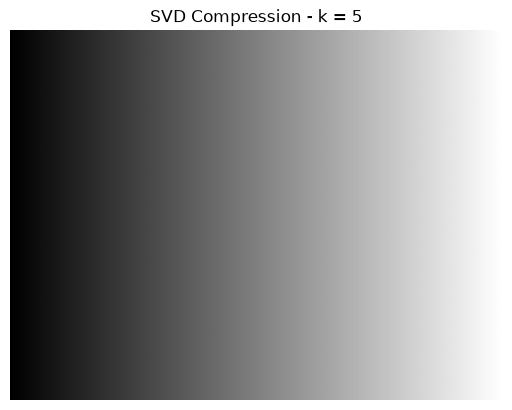

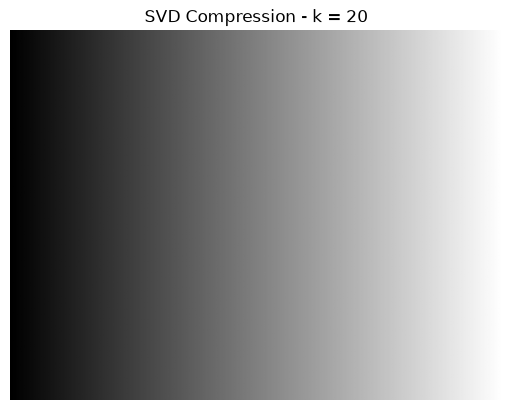

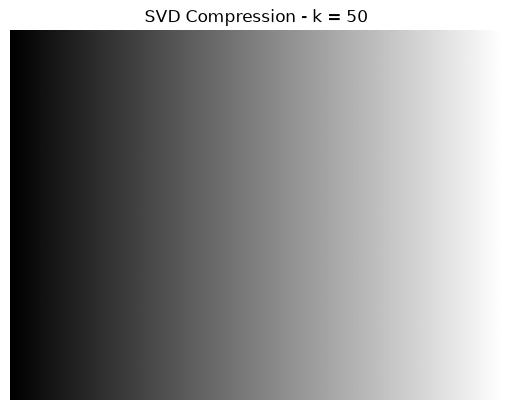

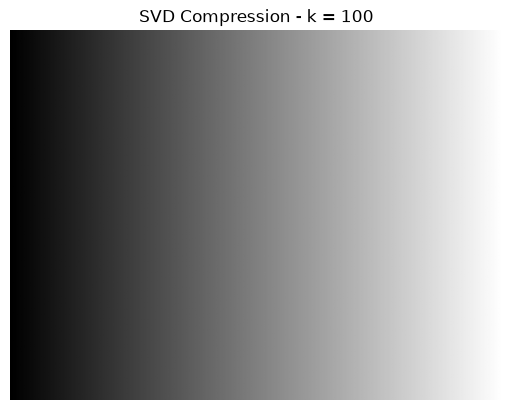

In [133]:
# 6. Display compressed images

for k in [5, 20, 50, 100]:

    compressed = compress(image, k)

    plt.imshow(
        compressed,
        cmap="gray"
    )

    plt.title(f"SVD Compression - k = {k}")
    plt.axis("off")
    plt.show()

# Task-5

In [ ]:
# Set seed so we get the same data every time
np.random.seed(42)

# Number of data points
n = 300

# Generate two random variables
x = np.random.normal(0, 1, n)
noise = np.random.normal(0, 0.5, n)

# Make y correlated with x
y = 2 * x + noise

# Combine x and y into a 2D dataset
X = np.column_stack((x, y))

print("Data shape:", X.shape)

Data shape: (300, 2)


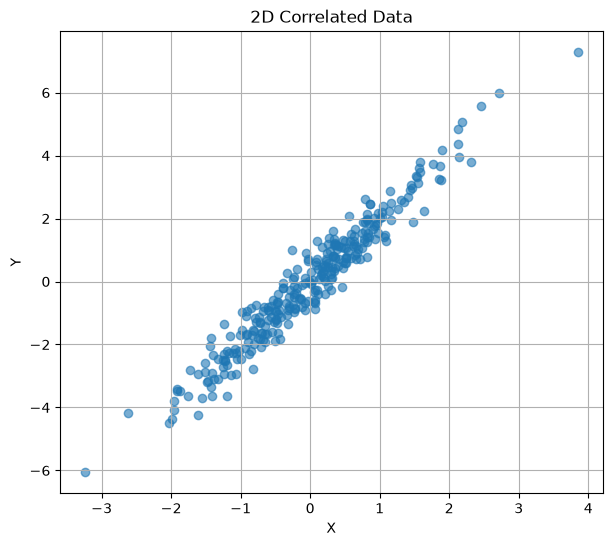

In [135]:
# 2. VISUALIZE THE CORRELATED DATA
plt.figure(figsize=(7, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    alpha=0.6
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("2D Correlated Data")

plt.grid()
plt.show()

In [136]:
# 3. CENTER THE DATA
# Calculate mean of each column
mean = np.mean(X, axis=0)

# Subtract mean from every data point
X_centered = X - mean

print("Mean:")
print(mean)

print("\nCentered data shape:")
print(X_centered.shape)

Mean:
[-0.00554856 -0.02184211]

Centered data shape:
(300, 2)


In [137]:
# 4. CALCULATE COVARIANCE MATRIX

cov_matrix = np.cov(
    X_centered,
    rowvar=False
)

print("\nCovariance Matrix:")
print(cov_matrix)


Covariance Matrix:
[[0.96863722 1.91810721]
 [1.91810721 4.02905718]]


In [138]:
# 5. CALCULATE EIGENVALUES AND EIGENVECTORS

eigenvalues, eigenvectors = np.linalg.eigh(
    cov_matrix
)

print("\nEigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)



Eigenvalues:
[0.04514024 4.95255416]

Eigenvectors:
[[-0.9010083   0.43380184]
 [ 0.43380184  0.9010083 ]]


In [139]:
# 6. SORT EIGENVALUES FROM LARGEST TO SMALLEST

# Get indices that sort eigenvalues in descending order
indices = np.argsort(eigenvalues)[::-1]

# Reorder eigenvalues
eigenvalues = eigenvalues[indices]

# Reorder eigenvectors
eigenvectors = eigenvectors[:, indices]

print("\nSorted Eigenvalues:")
print(eigenvalues)

print("\nSorted Eigenvectors:")
print(eigenvectors)


Sorted Eigenvalues:
[4.95255416 0.04514024]

Sorted Eigenvectors:
[[ 0.43380184 -0.9010083 ]
 [ 0.9010083   0.43380184]]


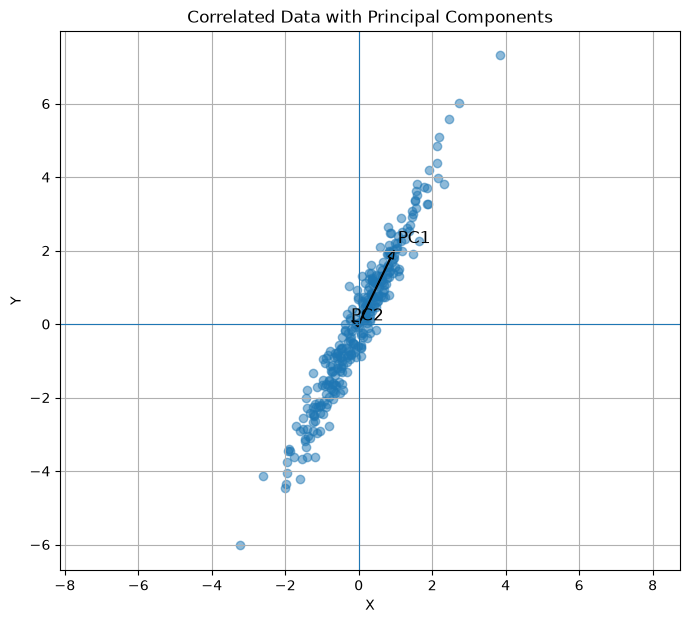

In [140]:
# 7. VISUALIZE DATA WITH EIGENVECTORS

plt.figure(figsize=(8, 7))

# Plot data
plt.scatter(
    X_centered[:, 0],
    X_centered[:, 1],
    alpha=0.5
)

# Origin
origin = np.array([0, 0])

# Draw eigenvectors
for i in range(2):

    vector = eigenvectors[:, i]

    # Scale vector by eigenvalue
    scaled_vector = vector * np.sqrt(eigenvalues[i])

    plt.arrow(
        0,
        0,
        scaled_vector[0],
        scaled_vector[1],
        width=0.02,
        head_width=0.15,
        length_includes_head=True
    )

    plt.text(
        scaled_vector[0] * 1.1,
        scaled_vector[1] * 1.1,
        f"PC{i + 1}",
        fontsize=12
    )


plt.xlabel("X")
plt.ylabel("Y")

plt.title(
    "Correlated Data with Principal Components"
)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.grid()
plt.axis("equal")

plt.show()

In [141]:
# 8. FIND THE FIRST PRINCIPAL COMPONENT

first_pc = eigenvectors[:, 0]

print("\nFirst Principal Component:")
print(first_pc)

print(
    "\nLargest Eigenvalue:",
    eigenvalues[0]
)


First Principal Component:
[0.43380184 0.9010083 ]

Largest Eigenvalue: 4.952554160574071


In [142]:
# 9. APPLY SVD DIRECTLY TO CENTERED DATA

U, s, Vt = np.linalg.svd(
    X_centered,
    full_matrices=False
)

print("\nSVD Results")

print("U shape:", U.shape)
print("Singular values shape:", s.shape)
print("Vt shape:", Vt.shape)

print("\nSingular values:")
print(s)

print("\nVt:")
print(Vt)


SVD Results
U shape: (300, 2)
Singular values shape: (2,)
Vt shape: (2, 2)

Singular values:
[38.48134215  3.67381702]

Vt:
[[-0.43380184 -0.9010083 ]
 [-0.9010083   0.43380184]]


In [143]:
# 10. COMPARE SVD DIRECTIONS WITH EIGENVECTORS

print("\nEigenvectors:")
print(eigenvectors)

print("\nRows of Vt:")
print(Vt)


# Eigenvectors are columns
# Vt contains the same directions as rows

print("\nFirst eigenvector:")
print(eigenvectors[:, 0])

print("\nFirst row of Vt:")
print(Vt[0, :])


Eigenvectors:
[[ 0.43380184 -0.9010083 ]
 [ 0.9010083   0.43380184]]

Rows of Vt:
[[-0.43380184 -0.9010083 ]
 [-0.9010083   0.43380184]]

First eigenvector:
[0.43380184 0.9010083 ]

First row of Vt:
[-0.43380184 -0.9010083 ]


In [144]:
# 11. CHECK THE DIRECTION

# The vectors can have opposite signs.
# For example:
#
# [0.4, 0.9]
#
# and
#
# [-0.4, -0.9]
#
# point in the same line.

direction_similarity = abs(
    np.dot(
        eigenvectors[:, 0],
        Vt[0, :]
    )
)

print(
    "\nDirection similarity:",
    direction_similarity
)


Direction similarity: 1.0


In [145]:
# 12. PROJECT DATA ONTO FIRST PRINCIPAL COMPONENT

# First principal component
pc1 = eigenvectors[:, 0]

# Convert 2D data into 1D
X_1D = X_centered @ pc1

print("\nOriginal data shape:")
print(X_centered.shape)

print("\nProjected data shape:")
print(X_1D.shape)


Original data shape:
(300, 2)

Projected data shape:
(300,)


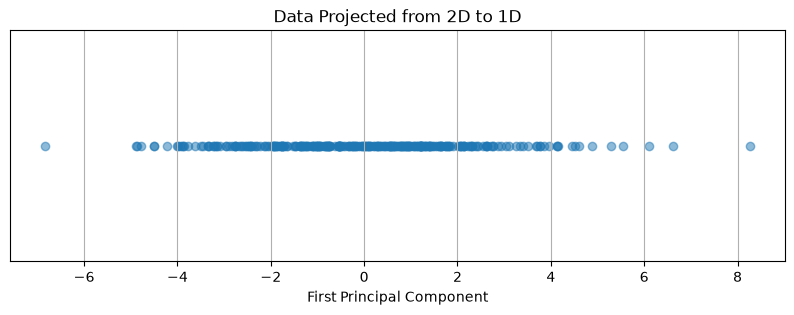

In [146]:
# 13. DISPLAY 1D PCA PROJECTION

plt.figure(figsize=(10, 3))

plt.scatter(
    X_1D,
    np.zeros_like(X_1D),
    alpha=0.5
)

plt.xlabel("First Principal Component")
plt.yticks([])

plt.title(
    "Data Projected from 2D to 1D"
)

plt.grid()
plt.show()

In [147]:
# 14. CALCULATE VARIANCE RETAINED

# Total variance
total_variance = np.sum(eigenvalues)

# Variance captured by first PC
first_pc_variance = eigenvalues[0]

# Percentage of variance retained
variance_retained = (
    first_pc_variance
    /
    total_variance
) * 100

print("\nVariance Analysis")

print(
    "Total variance:",
    total_variance
)

print(
    "Variance captured by PC1:",
    first_pc_variance
)

print(
    "Variance retained:",
    variance_retained,
    "%"
)


Variance Analysis
Total variance: 4.997694399713065
Variance captured by PC1: 4.952554160574071
Variance retained: 99.09677872377338 %


In [148]:
# 15. SINGULAR VALUES VS EIGENVALUES

# For centered data:
#
# Eigenvalue = singular_value² / (n - 1)

calculated_eigenvalues = (
    s ** 2
    /
    (n - 1)
)

print("\nEigenvalues from covariance matrix:")
print(eigenvalues)

print("\nEigenvalues calculated from SVD:")
print(calculated_eigenvalues)


Eigenvalues from covariance matrix:
[4.95255416 0.04514024]

Eigenvalues calculated from SVD:
[4.95255416 0.04514024]


In [149]:
# 16. VERIFY THEY ARE ALMOST THE SAME
print(
    "\nAre the eigenvalues approximately equal"
)

print(
    np.allclose(
        eigenvalues,
        calculated_eigenvalues
    )
)


Are the eigenvalues approximately equal
True


In [150]:
# 17. RECONSTRUCT DATA USING ONLY FIRST PC

# Keep only first principal component
X_reduced = X_1D.reshape(-1, 1)

# Reconstruct back to 2D
X_reconstructed = (
    X_reduced
    @ pc1.reshape(1, -1)
)

# Add the original mean back
X_reconstructed = (
    X_reconstructed
    + mean
)

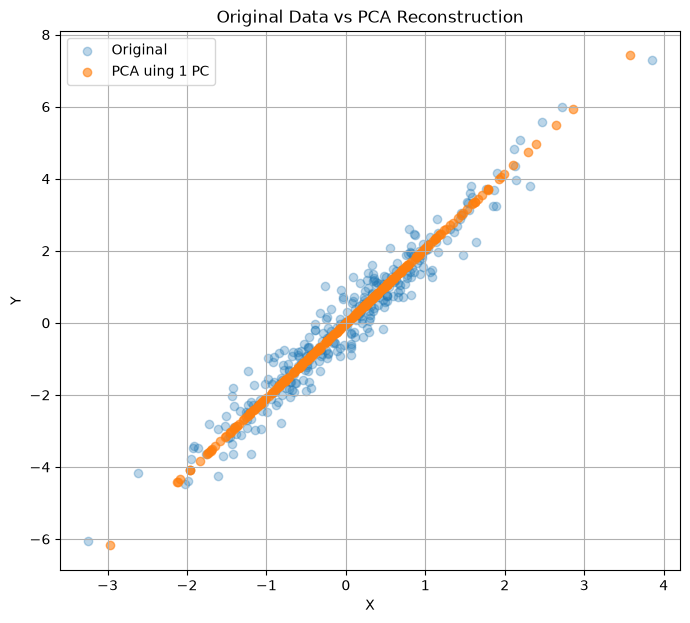

In [151]:
# 18. VISUALIZE ORIGINAL AND PCA RECONSTRUCTED DATA

plt.figure(figsize=(8, 7))

# Original data
plt.scatter(
    X[:, 0],
    X[:, 1],
    alpha=0.3,
    label="Original"
)

# Reconstructed data
plt.scatter(
    X_reconstructed[:, 0],
    X_reconstructed[:, 1],
    alpha=0.6,
    label="PCA uing 1 PC"
)

plt.xlabel("X")
plt.ylabel("Y")

plt.title(
    "Original Data vs PCA Reconstruction"
)

plt.legend()
plt.grid()

plt.show()

In [152]:
# 19. FINAL SUMMARY

print("TASK 05 FINAL SUMMARY")

print("Original data dimensions:",X.shape)

print("Covariance matrix shape:",cov_matrix.shape)

print("Largest eigenvalue:",eigenvalues[0])

print("First principal component:",first_pc)

print("Number of dimensions after PCA:",X_1D.ndim)

print("Variance retained by first PC:",round(variance_retained, 2),"%")

print("SVD and covariance eigenvalues match:",np.allclose(eigenvalues,calculated_eigenvalues))

TASK 05 FINAL SUMMARY
Original data dimensions: (300, 2)
Covariance matrix shape: (2, 2)
Largest eigenvalue: 4.952554160574071
First principal component: [0.43380184 0.9010083 ]
Number of dimensions after PCA: 1
Variance retained by first PC: 99.1 %
SVD and covariance eigenvalues match: True
